In [1]:
import pandas as pd

#combine both csv files into a single dataframe

df1 = pd.read_csv('high_popularity_spotify_data.csv')
df2 = pd.read_csv('low_popularity_spotify_data.csv')

#Label the dataframes before combining

df1['popularity_label'] = 'high'
df2['popularity_label'] = 'low'

#combine the dataframes

combined_df = pd.concat([df1, df2], ignore_index=True)

#clean the dataframe by removing duplicates and handling missing values
combined_df.drop_duplicates(inplace=True)

Features = ['energy', 'danceability', 'valence', 'loudness', 'tempo',
    'acousticness', 'instrumentalness', 'speechiness', 'liveness', 'mode']

combined_df.dropna(subset=Features + ['playlist_genre', 'popularity_label'], inplace=True)
combined_df.fillna('unknown', inplace=True)

#save the cleaned combined dataframe to a new csv file
combined_df.to_csv('combined_spotify_data.csv', index=False)

# Display the first few rows of the combined dataframe
print(combined_df.head())

   energy    tempo  danceability playlist_genre  loudness  liveness  valence  \
0   0.592  157.969         0.521            pop    -7.777     0.122    0.535   
1   0.507  104.978         0.747            pop   -10.171     0.117    0.438   
2   0.808  108.548         0.554            pop    -4.169     0.159    0.372   
3   0.910  112.966         0.670            pop    -4.070     0.304    0.786   
4   0.783  149.027         0.777            pop    -4.477     0.355    0.939   

            track_artist  time_signature  speechiness  ...  \
0  Lady Gaga, Bruno Mars             3.0       0.0304  ...   
1          Billie Eilish             4.0       0.0358  ...   
2          Gracie Abrams             4.0       0.0368  ...   
3      Sabrina Carpenter             4.0       0.0634  ...   
4       ROSÉ, Bruno Mars             4.0       0.2600  ...   

           track_album_id mode  key duration_ms acousticness  \
0  10FLjwfpbxLmW8c25Xyc2N  0.0  6.0    251668.0       0.3080   
1  7aJuG4TFXa2hmE4

In [ ]:
# Descretize numerical features into categorical bins

def descretize_features (series, bins, labels):
    return pd.cut(series, bins=bins, labels=labels, include_lowest=True)


combined_df['energy_discretize'] = descretize_features(combined_df['energy'], bins=[0, 0.3, 0.7, 1], labels=['low_energy', 'medium_energy', 'high_energy'])
combined_df['danceability_discretize'] = descretize_features(combined_df['danceability'], bins=[0, 0.3, 0.7, 1], labels=['low_danceability', 'medium_danceability', 'high_danceability'])
combined_df['valence_discretize'] = descretize_features(combined_df['valence'], bins=[0, 0.3, 0.7, 1], labels=['low_valence', 'medium_valence', 'high_valence'])
combined_df['loudness_discretize'] = descretize_features(combined_df['loudness'], bins=[-60, -30, -10, 0], labels=['low_loudness', 'medium_loudness', 'high_loudness'])
combined_df['tempo_discretize'] = descretize_features(combined_df['tempo'], bins=[0, 60, 120, 200], labels=['slow_tempo', 'medium_tempo', 'fast_tempo'])
combined_df['acousticness_discretize'] = descretize_features(combined_df['acousticness'], bins=[0, 0.3, 0.7, 1], labels=['low_acousticness', 'medium_acousticness', 'high_acousticness'])
combined_df['instrumentalness_discretize'] = descretize_features(combined_df['instrumentalness'], bins=[0, 0.3, 0.7, 1], labels=['low_instrumentalness', 'medium_instrumentalness', 'high_instrumentalness'])
combined_df['speechiness_discretize'] = descretize_features(combined_df['speechiness'], bins=[0, 0.3, 0.7, 1], labels=['low_speechiness', 'medium_speechiness', 'high_speechiness'])
combined_df['liveness_discretize'] = descretize_features(combined_df['liveness'], bins=[0, 0.3, 0.7, 1], labels=['low_liveness', 'medium_liveness', 'high_liveness'])
combined_df['mode_discretize'] = combined_df['mode'].map({0: 'minor', 1: 'major'})

#display the first few rows of the descretized dataframe
print(combined_df.head())

#Arm columns
arm_columns = ["popularity_label",
               "energy_discretize",
               "danceability_discretize",
               "valence_discretize",
               "loudness_discretize",
               "tempo_discretize",
               "acousticness_discretize",
               "instrumentalness_discretize",
               "speechiness_discretize",
               "liveness_discretize",
               "mode_discretize",
               "playlist_genre",]

arm_columns =  [col for col in arm_columns if col in combined_df.columns]

arm_df = combined_df[arm_columns].copy()

#save the descretized dataframe to a new csv file
combined_df.to_csv('descretized_spotify_data.csv', index=False)
print(arm_df.head())
print("Arm dataframe columns:", arm_df.columns.tolist())
print(arm_df.iloc[0].tolist())

#convert the arm dataframe to a list of transactions
transactions = []
for _, row in arm_df.iterrows():
    transaction = [f"{col}={row[col]}" for col in arm_df.columns]
    transactions.append(transaction)

#display the first transaction
print(transactions[0])



   energy    tempo  danceability playlist_genre  loudness  liveness  valence  \
0   0.592  157.969         0.521            pop    -7.777     0.122    0.535   
1   0.507  104.978         0.747            pop   -10.171     0.117    0.438   
2   0.808  108.548         0.554            pop    -4.169     0.159    0.372   
3   0.910  112.966         0.670            pop    -4.070     0.304    0.786   
4   0.783  149.027         0.777            pop    -4.477     0.355    0.939   

            track_artist  time_signature  speechiness  ...  energy_discretize  \
0  Lady Gaga, Bruno Mars             3.0       0.0304  ...      medium_energy   
1          Billie Eilish             4.0       0.0358  ...      medium_energy   
2          Gracie Abrams             4.0       0.0368  ...        high_energy   
3      Sabrina Carpenter             4.0       0.0634  ...        high_energy   
4       ROSÉ, Bruno Mars             4.0       0.2600  ...        high_energy   

  danceability_discretize valenc

In [ ]:
#Encode the transactions using one-hot encoding
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import fpgrowth, association_rules

te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
df = pd.DataFrame(te_ary, columns=te.columns_)
print("✅ Encoded transactions into a DataFrame.")
print(df.head())


#Generate frequent itemsets using the FP-Growth algorithm
frequent_itemsets = fpgrowth(df, min_support=0.01, use_colnames=True)
print("✅ Generated frequent itemsets.")
print(frequent_itemsets)



✅ Encoded transactions into a DataFrame.
   acousticness_discretize=high_acousticness  \
0                                      False   
1                                      False   
2                                      False   
3                                      False   
4                                      False   

   acousticness_discretize=low_acousticness  \
0                                     False   
1                                      True   
2                                      True   
3                                      True   
4                                      True   

   acousticness_discretize=medium_acousticness  \
0                                         True   
1                                        False   
2                                        False   
3                                        False   
4                                        False   

   danceability_discretize=high_danceability  \
0                                     

In [ ]:
#rules
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.5)
rules = rules[rules['consequents'].apply(lambda x: any('popularity_label=' in item for item in x))]
print("Generated association rules.")
print(rules)

#split into high and low popularity rules
high_popularity_rules = rules[rules['consequents'].apply(lambda x: 'popularity_label=high' in x)]
low_popularity_rules = rules[rules['consequents'].apply(lambda x: 'popularity_label=low' in x)]

print("High Popularity Rules:")
print(high_popularity_rules)

print("Low Popularity Rules:")
print(low_popularity_rules)


high_popularity_rules.to_csv('popular_rules.csv', index=False)
low_popularity_rules.to_csv('unpopular_rules.csv', index=False)

#top rules
print("Popular top 5 rules:")
top_pop = high_popularity_rules.nlargest(5, 'lift')
for idx, row in top_pop.iterrows():
    print(f"  IF {', '.join(row['antecedents'])}")
    print(f"  THEN popularity_label=high")
    print(f"    Support: {row['support']:.3f}, Confidence: {row['confidence']:.3f}, Lift: {row['lift']:.2f}\n")


print("Unpopular top 5 rules:")
top_unpop = low_popularity_rules.nlargest(5, 'lift')
for idx, row in top_unpop.iterrows():
    print(f"  IF {', '.join(row['antecedents'])}")
    print(f"  THEN popularity_label=low")
    print(f"    Support: {row['support']:.3f}, Confidence: {row['confidence']:.3f}, Lift: {row['lift']:.2f}\n")

Generated association rules.
                                              antecedents  \
62          (danceability_discretize=medium_danceability)   
153     (danceability_discretize=medium_danceability, ...   
270     (danceability_discretize=medium_danceability, ...   
273     (danceability_discretize=medium_danceability, ...   
275     (liveness_discretize=low_liveness, mode_discre...   
...                                                   ...   
913454  (instrumentalness_discretize=high_instrumental...   
913455  (valence_discretize=low_valence, playlist_genr...   
913456  (playlist_genre=wellness, danceability_discret...   
913457  (playlist_genre=wellness, speechiness_discreti...   
913458                          (playlist_genre=wellness)   

                                              consequents  antecedent support  \
62                                 (popularity_label=low)            0.536232   
153                                (popularity_label=low)            0.30724

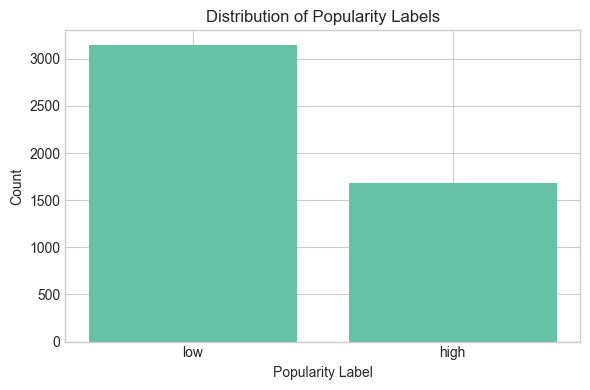

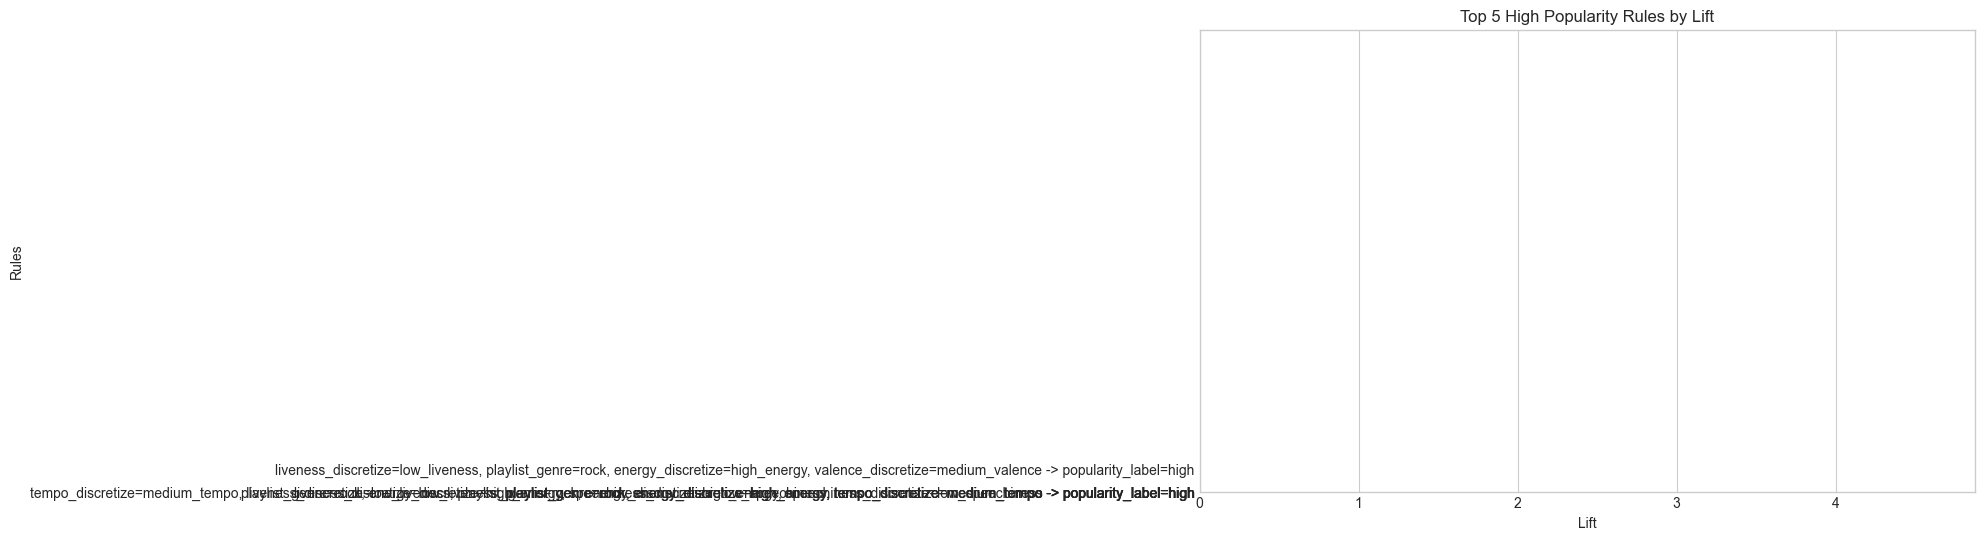

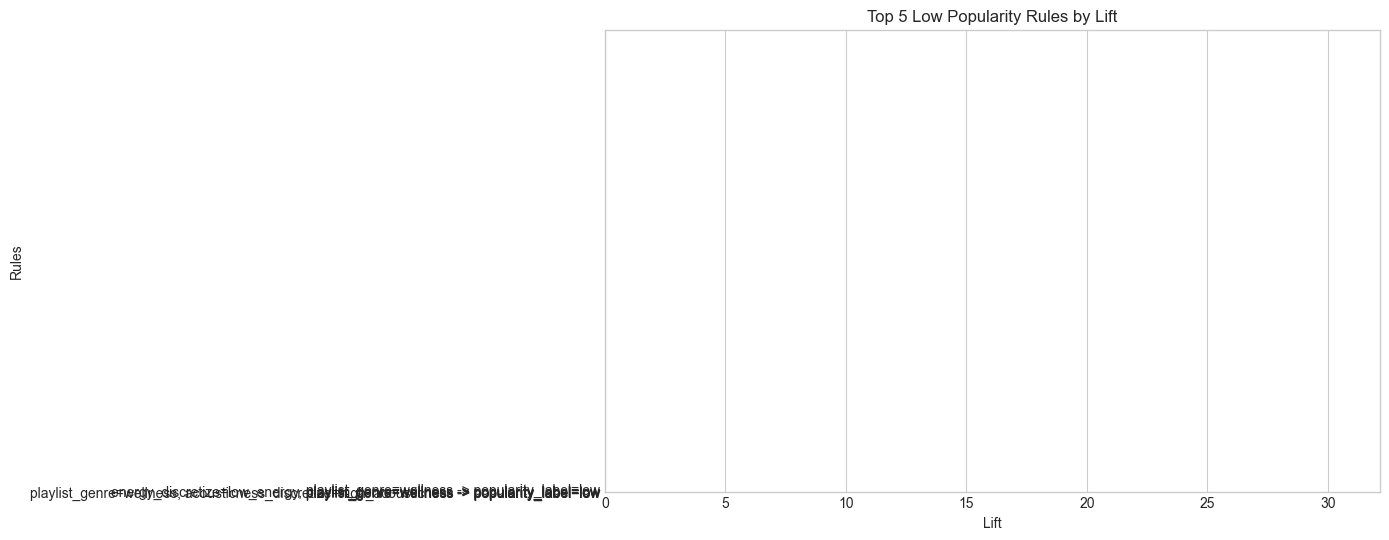

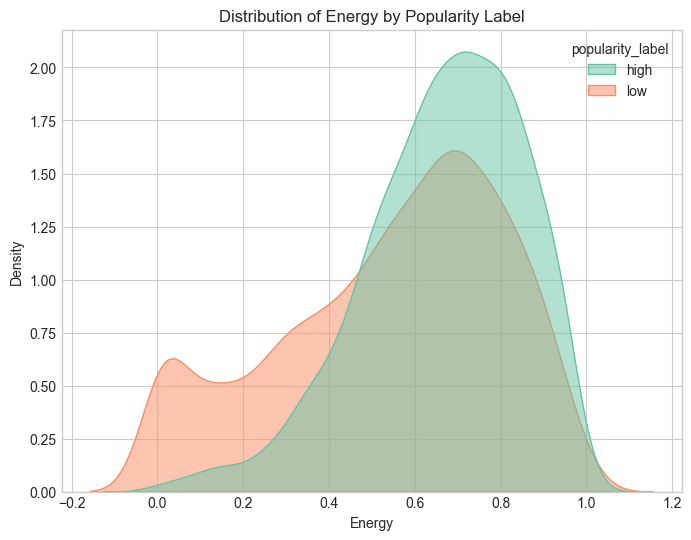

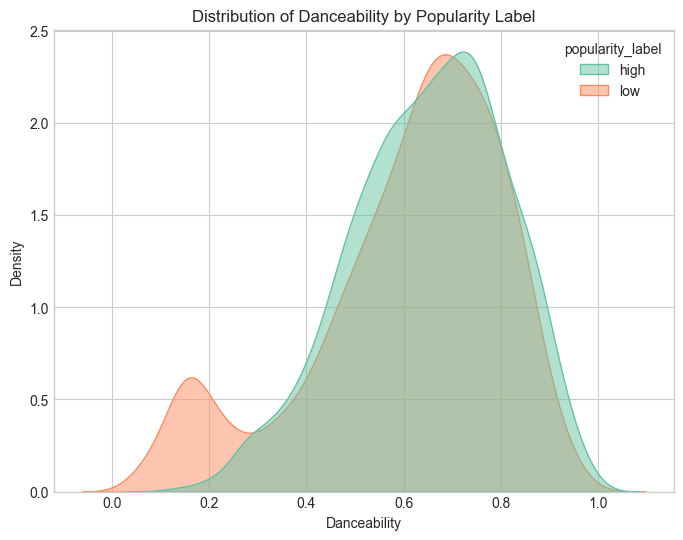

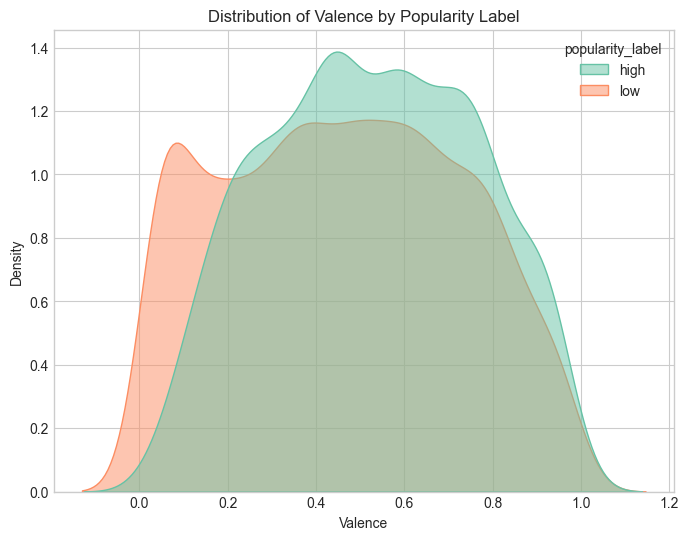

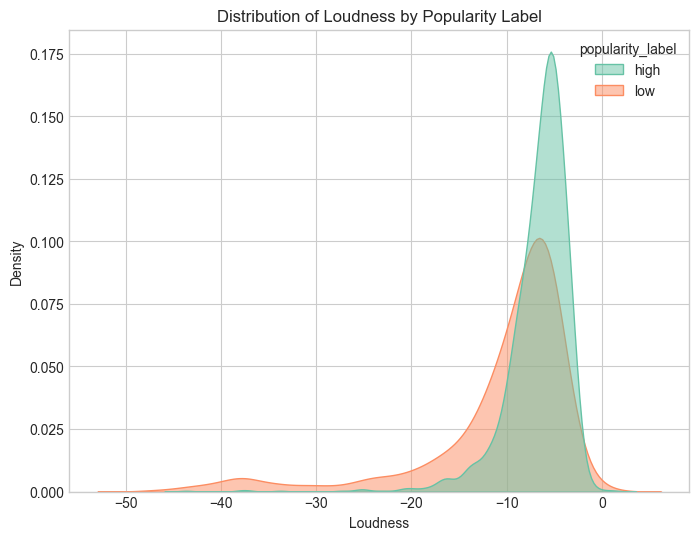

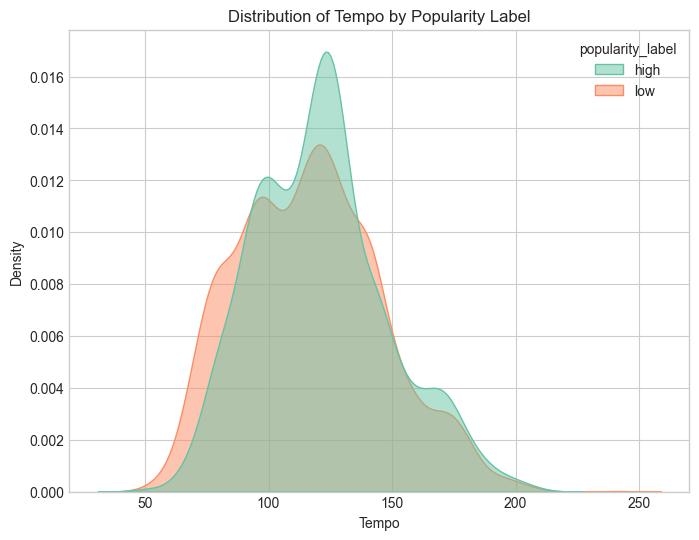

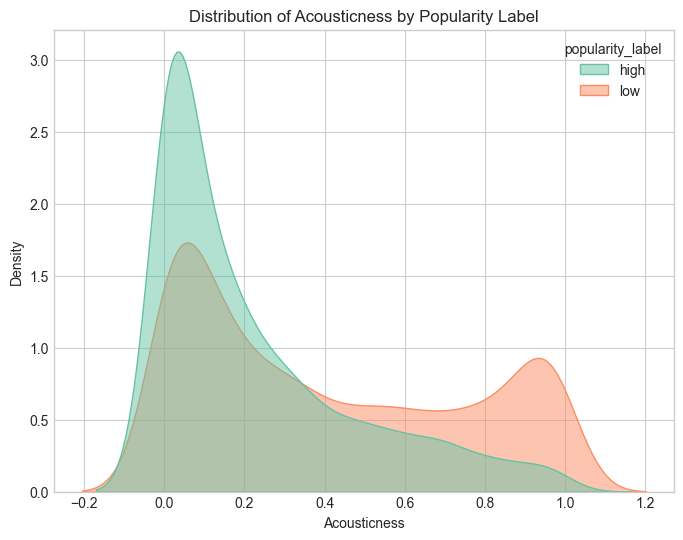

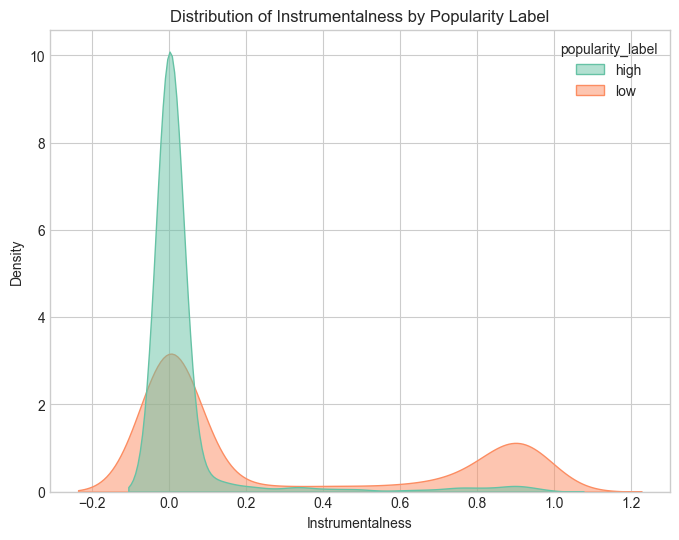

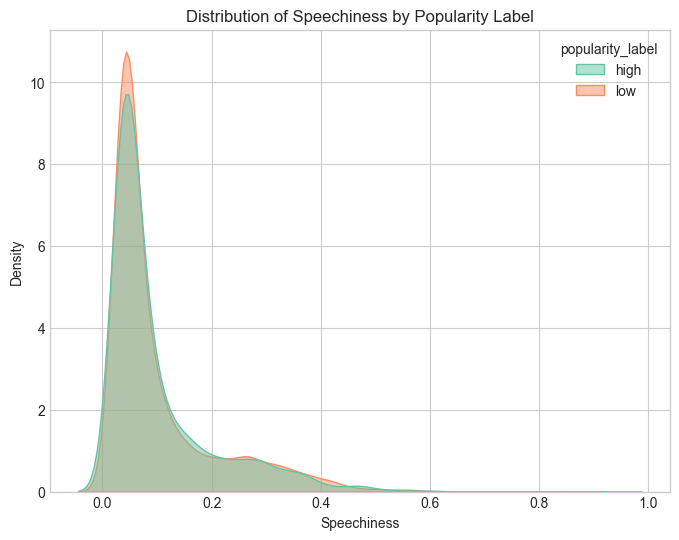

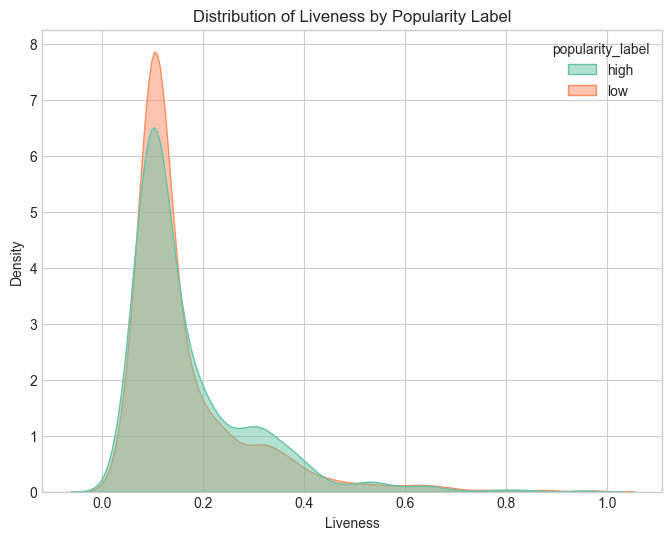

In [ ]:
#visuarlization
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize the distribution of popularity labels
plt.figure(figsize=(6, 4))
counts = combined_df['popularity_label'].value_counts()
plt.bar(counts.index, counts.values)
plt.title('Distribution of Popularity Labels')
plt.xlabel('Popularity Label')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

#visualize top 5 rules by lift for high popularity
top_pop = high_popularity_rules.nlargest(5, 'lift').copy()
top_pop['antecedent_str'] = top_pop['antecedents'].apply(lambda x: ', '.join(x))

plt.figure(figsize=(10, 6))
plt.barh(range(len(top_pop)), top_pop['lift'])
plt.yticks(range(len(top_pop)), top_pop['antecedent_str'])
plt.xlabel('Lift')
plt.title('Top 5 Rules → POPULAR Songs (by Lift)')
plt.gca().invert_yaxis()

for i, v in enumerate(top_pop['lift']):
    plt.text(v, i, f"{v:.2f}", va='center')

plt.tight_layout()
plt.show()

#visualize top 5 rules by lift for low popularity
top_unpop = low_popularity_rules.nlargest(5, 'lift').copy()
top_unpop['antecedent_str'] = top_unpop['antecedents'].apply(lambda x: ', '.join(x))

plt.figure(figsize=(10, 6))
plt.barh(range(len(top_unpop)), top_unpop['lift'])
plt.yticks(range(len(top_unpop)), top_unpop['antecedent_str'])
plt.xlabel('Lift')
plt.title('Top 5 Rules → UNPOPULAR Songs (by Lift)')
plt.gca().invert_yaxis()

for i, v in enumerate(top_unpop['lift']):
    plt.text(v, i, f"{v:.2f}", va='center')

plt.tight_layout()
plt.show()

#audio feature distributions
feature_columns = ['energy', 'danceability', 'valence', 'loudness', 'tempo',
                   'acousticness', 'instrumentalness', 'speechiness', 'liveness']
for feature in feature_columns:
    plt.figure(figsize=(8,6))
    sns.kdeplot(data=combined_df, x=feature, hue='popularity_label', fill=True, common_norm=False, alpha=0.5)
    plt.title(f'Distribution of {feature.capitalize()} by Popularity Label')
    plt.xlabel(feature.capitalize())
    plt.ylabel('Density')
    plt.show()




